<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/Bayesiyan_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Beta Regression: Garment Worker Productivity
### From Insight to Forecast — Part 1: Bayesian GLM

**Project:** From Insight to Forecast — Bayesian & Kalman Models for Garment Manufacturing Productivity  
**Dataset:** UCI Productivity Prediction of Garment Employees (Jan–Mar 2015)  
**Reference:** Imran et al. (2021) — *Mining the productivity data of the garment industry*

---
## Notebook Roadmap

| Section | Content |
|---------|--------|
| 1 | Setup & data loading |
| 2 | Exploratory driver analysis (descriptive) |
| 3 | Bayesian Beta regression — pooled model |
| 4 | Hierarchical model with team random effects |
| 5 | Nonlinear spline model for incentive |
| 6 | Interaction models (WIP × workers, incentive × WIP) |
| 7 | Model comparison (PSIS-LOO) |
| 8 | Posterior predictive checks & calibration |
| 9 | Classification proxy (low-day AUC vs. Imran 2021) |
| 10 | Prescriptive: uplift curves & threshold rules |
| 11 | What-if calculator (incentive / WIP / workers) |
| 12 | Heterogeneous effects: which teams benefit most |
| 13 | Full results report & comparison with paper |


## 0. Install & Import

In [1]:
# Install packages (Colab-safe)
!pip install pymc arviz pytensor pandas numpy scipy matplotlib seaborn scikit-learn --quiet

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import logit, expit
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
OUT = Path('bayesian_outputs')
OUT.mkdir(exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════
# COLUMN CONSTANTS — exactly match bayesian_glm_ready.csv schema
# Cleaning pipeline outputs:
#   split_code  : 0=train, 1=val, 2=test   (numeric, no text)
#   team_dept_idx: 0-based int, 24 groups   (12 teams × 2 departments)
#   *_s columns : StandardScaler on train only
# ═══════════════════════════════════════════════════════════════════════

# Standardised predictors (all ≈ N(0,1) on train set)
X_CORE = [
    'log_incentive_s',        # log(incentive+1), std
    'log_wip_imputed_s',      # log(wip_imputed+1), std; finishing dept = 0
    'log_over_time_s',        # log(over_time+1), std
    'log_smv_s',              # log(smv), std
    'log_workers_s',          # log(no_of_workers), std
    'targeted_productivity_s',
    'no_of_style_change_s',
    'sin_dow_s',              # cyclical weekday — sin component
    'cos_dow_s',              # cyclical weekday — cos component
    'wip_missing_flag',       # 1 = finishing dept (MNAR); binary, NOT scaled
    'dept_bin',               # 1 = sewing, 0 = finishing; binary, NOT scaled
]

# Raw interaction terms (will be standardised in §4)
X_INTERACT_RAW = [
    'incentive_x_log_wip',       # log_incentive × log_wip_imputed
    'log_wip_x_log_workers',     # log_wip_imputed × log_workers
    'incentive_x_workers',       # log_incentive × log_workers
]

# Constants from cleaning pipeline
GROUP_COL   = 'team_dept_idx'   # 24 unique groups
SPLIT_COL   = 'split_code'      # 0=train 1=val 2=test
N_GROUPS    = 24                # 12 teams × 2 departments
N_TEAMS     = 12

TARGET_BETA    = 'productivity_beta'    # y ∈ (0,1) for Beta likelihood
TARGET_LOGIT   = 'logit_productivity'  # logit(y) for DLM
TARGET_RAW     = 'actual_productivity'
TARGET_LOW     = 'low_productivity'     # 1 = below targeted_productivity
TARGET_LOW_ABS = 'low_productivity_abs' # 1 = actual_productivity < 0.70

LOW_THRESH  = 0.70
PAPER_INCTH = 69.5   # BDT — Imran et al. (2021) threshold

DOW_LABELS  = ['Sat','Sun','Mon','Tue','Wed','Thu']   # day_num 0–5

print(f'PyMC {pm.__version__}  |  ArviZ {az.__version__}')
print(f'X_CORE        : {len(X_CORE)} predictors')
print(f'X_INTERACT_RAW: {len(X_INTERACT_RAW)} (will be std-scaled in §4)')
print(f'Groups        : {N_GROUPS}')
print('Constants ready ✓')


PyMC 5.28.4  |  ArviZ 0.22.0
X_CORE        : 11 predictors
X_INTERACT_RAW: 3 (will be std-scaled in §4)
Groups        : 24
Constants ready ✓


## 1. Load Cleaned Data

Run your data cleaning notebook first (`Cleaned_data_1.ipynb`) and upload the resulting `garment_bayesian_glm.csv`.  
If starting from raw CSV, the cleaning pipeline is re-run here as a compact version.

In [2]:
# Upload bayesian_glm_ready.csv from modeling_ready_data/
from google.colab import files
print('Upload  bayesian_glm_ready.csv  (from modeling_ready_data/ folder)')
uploaded = files.upload()
GLM_PATH = list(uploaded.keys())[0]
df = pd.read_csv(GLM_PATH)

print(f'\nShape             : {df.shape}  (expect 1197 rows × ~44 cols)')
print(f'Total missing     : {df.isna().sum().sum()}  (must be 0)')
print(f'Groups            : {df[GROUP_COL].nunique()}  (expect 24)')
print(f'Teams             : {df["team"].nunique()}  (expect 12)')
print(f'Split counts      : {dict(zip(["train","val","test"], df[SPLIT_COL].value_counts().sort_index().values))}')

# Verify required columns
required = X_CORE + X_INTERACT_RAW + [
    GROUP_COL, SPLIT_COL,
    TARGET_BETA, TARGET_LOGIT, TARGET_RAW, TARGET_LOW, TARGET_LOW_ABS,
    'log_incentive', 'log_wip_imputed', 'log_workers',
    'incentive_above_695', 'wip_missing_flag', 'dept_bin',
    'workers_per_smv', 'cum_overtime_team', 'day_num',
]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    print(f'\n⚠  Missing columns: {missing_cols}')
    print('→ Re-run the cleaning notebook and re-export bayesian_glm_ready.csv')
else:
    print('\nAll required columns present ✓')

# Verify target
assert df[TARGET_BETA].between(0,1,inclusive='neither').all(),     'productivity_beta has boundary values!'
assert df[TARGET_LOGIT].isna().sum()==0, 'logit_productivity has NaN'
print(f'productivity_beta ∈ ({df[TARGET_BETA].min():.6f}, {df[TARGET_BETA].max():.6f}) ✓')

# Split masks
train_mask = df[SPLIT_COL]==0
val_mask   = df[SPLIT_COL]==1
test_mask  = df[SPLIT_COL]==2
train = df[train_mask].reset_index(drop=True)
val   = df[val_mask  ].reset_index(drop=True)
test  = df[test_mask ].reset_index(drop=True)

print(f'\nTrain {len(train)} | Val {len(val)} | Test {len(test)}')
print(f'Low-day rate (train, vs target)  : {train[TARGET_LOW].mean()*100:.1f}%')
print(f'Low-day rate (train, abs <0.70)  : {train[TARGET_LOW_ABS].mean()*100:.1f}%')
df.head(3)


Upload  bayesian_glm_ready.csv  (from modeling_ready_data/ folder)


Saving bayesian_glm_ready.csv to bayesian_glm_ready.csv

Shape             : (1197, 54)  (expect 1197 rows × ~44 cols)
Total missing     : 0  (must be 0)
Groups            : 24  (expect 24)
Teams             : 12  (expect 12)
Split counts      : {'train': np.int64(823), 'val': np.int64(182), 'test': np.int64(192)}

All required columns present ✓
productivity_beta ∈ (0.233928, 0.999582) ✓

Train 823 | Val 182 | Test 192
Low-day rate (train, vs target)  : 24.8%
Low-day rate (train, abs <0.70)  : 29.2%


,t,team,dept_bin,team_dept_idx,split_code,quarter,day_num,week_of_study,actual_productivity,productivity_beta,...,targeted_productivity_s,targeted_productivity_s.1,no_of_style_change_s,no_of_style_change_s.1,sin_dow_s,sin_dow_s.1,cos_dow_s,cos_dow_s.1,t_s,t_s.1
0,0,1,0,0,0,1,5,1,0.886500,0.886177,...,-0.866701,-0.866701,-1.099295,-1.099295,-1.099295,-1.099295,-1.329302,-1.329302,-1.329302,-1.329302
1,0,1,1,12,0,1,5,1,0.750428,0.750219,...,0.580141,0.580141,1.071580,1.071580,1.071580,1.071580,0.916668,0.916668,0.916668,0.916668
2,0,2,0,4,0,1,5,1,0.755167,0.754953,...,-0.866701,-0.866701,-1.099295,-1.099295,-1.099295,-1.099295,-1.329302,-1.329302,-1.329302,-1.329302


## 2. Exploratory Driver Analysis

Before modeling, we visualise relationships between covariates and productivity to validate prior choices.

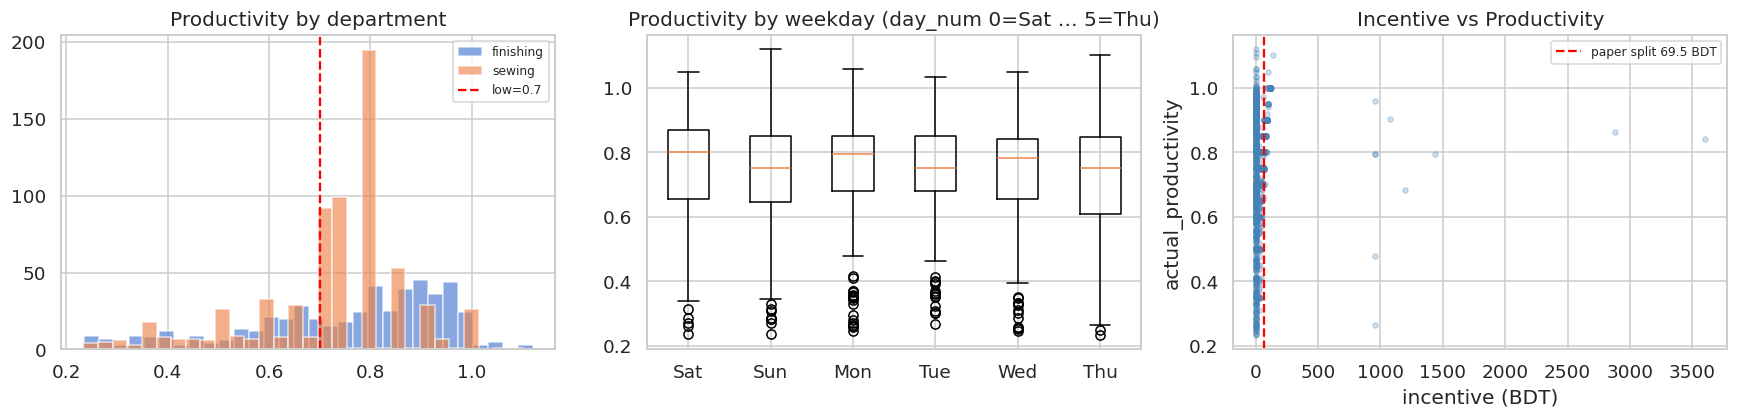

In [3]:
# ── 3.1 Productivity overview ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for db, lbl in [(0,'finishing'),(1,'sewing')]:
    axes[0].hist(df.loc[df['dept_bin']==db, TARGET_RAW],
                 bins=30, alpha=0.65, label=lbl, edgecolor='white')
axes[0].axvline(LOW_THRESH, color='red', ls='--', label=f'low={LOW_THRESH}')
axes[0].set_title('Productivity by department'); axes[0].legend(fontsize=8)

boxes = [df.loc[df['day_num']==i, TARGET_RAW].dropna() for i in range(6)]
axes[1].boxplot(boxes, labels=DOW_LABELS)
axes[1].set_title('Productivity by weekday (day_num 0=Sat … 5=Thu)')

inc_raw = np.expm1(df['log_incentive'])   # recover BDT from log_incentive
axes[2].scatter(inc_raw, df[TARGET_RAW], alpha=0.25, s=12, c='steelblue')
axes[2].axvline(PAPER_INCTH, color='red', ls='--',
                label=f'paper split {PAPER_INCTH} BDT')
axes[2].set_xlabel('incentive (BDT)'); axes[2].set_ylabel(TARGET_RAW)
axes[2].set_title('Incentive vs Productivity'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT/'01_eda_overview.png', bbox_inches='tight'); plt.show()


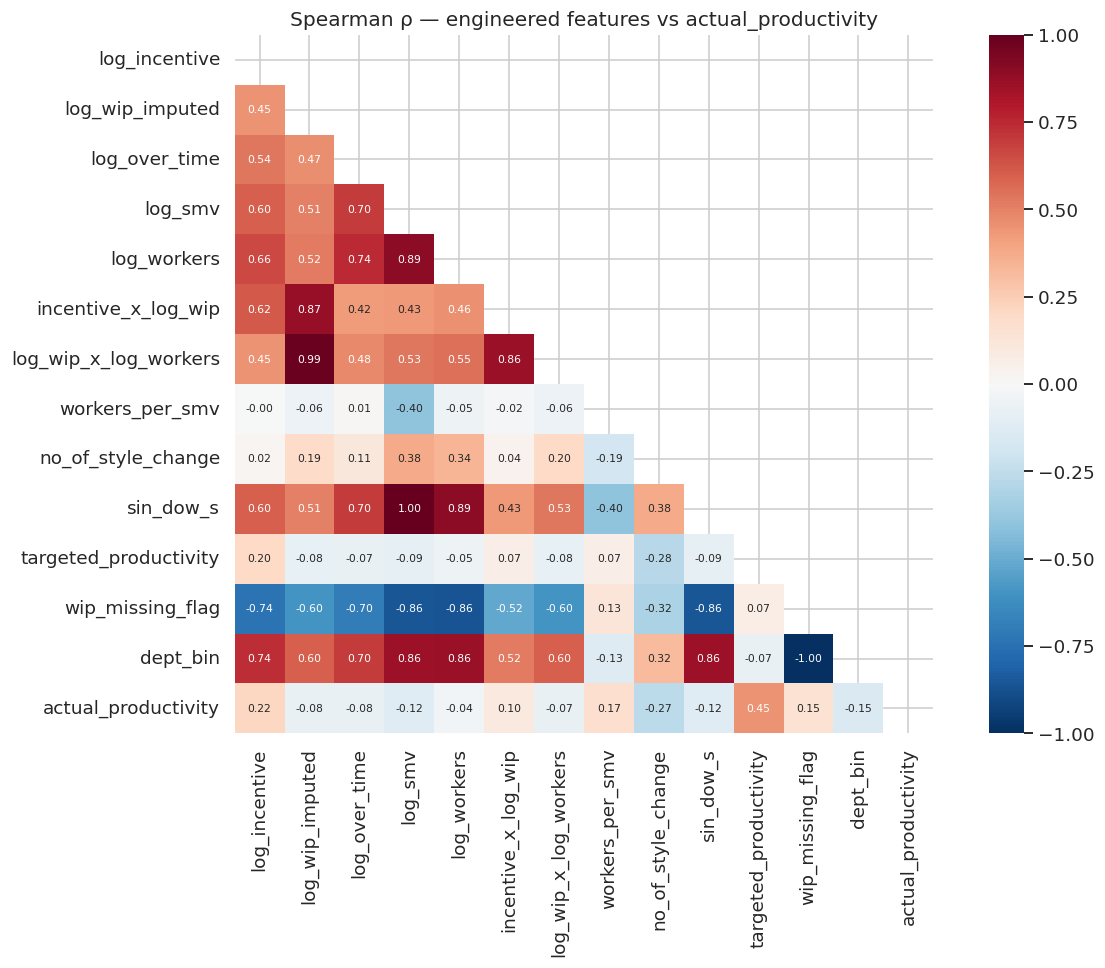

Top correlates with actual_productivity:
targeted_productivity    0.448375
no_of_style_change       0.265829
log_incentive            0.217064
workers_per_smv          0.170853
wip_missing_flag         0.151051
dept_bin                 0.151051
sin_dow_s                0.122303
log_smv                  0.122303
incentive_x_log_wip      0.099517
log_wip_imputed          0.077849
Name: actual_productivity, dtype: float64


In [4]:
# ── 3.2 Spearman correlation heatmap ──────────────────────────────────────────
DRIVER_COLS = [c for c in [
    'log_incentive','log_wip_imputed','log_over_time','log_smv','log_workers',
    'incentive_x_log_wip','log_wip_x_log_workers','workers_per_smv',
    'no_of_style_change','sin_dow_s','targeted_productivity',
    'wip_missing_flag','dept_bin', TARGET_RAW
] if c in df.columns]

corr = df[DRIVER_COLS].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, annot_kws={'size':7})
ax.set_title('Spearman ρ — engineered features vs actual_productivity')
plt.tight_layout()
plt.savefig(OUT/'02_spearman_heatmap.png', bbox_inches='tight'); plt.show()

print('Top correlates with actual_productivity:')
print(corr[TARGET_RAW].drop(TARGET_RAW).abs().sort_values(ascending=False).head(10))


In [5]:
# ── 3.3 Paper threshold: incentive_above_695 (already in cleaned data) ──────
above = df[df['incentive_above_695']==1][TARGET_RAW]
below = df[df['incentive_above_695']==0][TARGET_RAW]
_, pval = stats.mannwhitneyu(above, below, alternative='greater')

print('=== Incentive > 69.5 BDT (incentive_above_695 column) ===')
print(f'  Mean above : {above.mean():.4f}  (n={len(above)})')
print(f'  Mean below : {below.mean():.4f}  (n={len(below)})')
print(f'  p-value    : {pval:.4e}  ({"significant" if pval<0.05 else "not significant"})')

low_a = (above < LOW_THRESH).mean()*100
low_b = (below < LOW_THRESH).mean()*100
print(f'  % low-day above 69.5 : {low_a:.1f}%')
print(f'  % low-day below 69.5 : {low_b:.1f}%')
print(f'  Risk reduction       : {low_b-low_a:.1f} pp')

# Calendar effects (using pre-computed day_num)
print('\n=== Low-day rate by weekday (day_num) ===')
lp_dow = df.groupby('day_num')[TARGET_LOW].mean()*100
lp_dow.index = DOW_LABELS
print(lp_dow.round(1).to_string())


=== Incentive > 69.5 BDT (incentive_above_695 column) ===
  Mean above : 0.8974  (n=106)
  Mean below : 0.7193  (n=1091)
  p-value    : 6.1298e-33  (significant)
  % low-day above 69.5 : 2.8%
  % low-day below 69.5 : 33.2%
  Risk reduction       : 30.4 pp

=== Low-day rate by weekday (day_num) ===
Sat    24.6
Sun    31.5
Mon    23.1
Tue    24.4
Wed    25.0
Thu    32.7


## 3. Data Preparation for PyMC

In [7]:
# ── Standardise interaction terms on train only ────────────────────────────────
# These are raw log-product columns; the *_s columns don't exist yet
scaler_int = StandardScaler()
scaler_int.fit(train[X_INTERACT_RAW])

X_INTERACT_S = [c+'_s' for c in X_INTERACT_RAW]
for split_df in [df, train, val, test]:
    arr = scaler_int.transform(split_df[X_INTERACT_RAW])
    for i, cn in enumerate(X_INTERACT_S):
        split_df[cn] = arr[:, i]

# ── Core arrays (X_CORE predictors only) ──────────────────────────────────────
y_train  = train[TARGET_BETA].values.astype(np.float64)
X_train  = train[X_CORE].values.astype(np.float64)
X_val    = val[X_CORE].values.astype(np.float64)
X_test   = test[X_CORE].values.astype(np.float64)

grp_train = train[GROUP_COL].values.astype(int)
grp_val   = val[GROUP_COL].values.astype(int)
grp_test  = test[GROUP_COL].values.astype(int)

# ── Extended arrays (core + interaction) ──────────────────────────────────────
ALL_PRED  = X_CORE + X_INTERACT_S
Xi_train  = train[ALL_PRED].values.astype(np.float64)
Xi_val    = val[ALL_PRED].values.astype(np.float64)
Xi_test   = test[ALL_PRED].values.astype(np.float64)

N_CORE  = X_train.shape[1]    # 11
N_INTER = Xi_train.values.shape[1] if hasattr(Xi_train,'values') else Xi_train.shape[1]  # 14

# ── Label lists for plots ──────────────────────────────────────────────────────
CORE_LABELS = [
    'log incentive','log WIP','log overtime','log SMV','log workers',
    'targeted prod','style changes','sin DOW','cos DOW',
    'WIP missing (MNAR)','dept (sewing=1)'
]
INTER_LABELS = CORE_LABELS + ['incentive×WIP','WIP×workers','incentive×workers']

# ── Recover raw incentive & log_wip for what-if (scaler params from train) ────
LI_MEAN = float(train['log_incentive'].mean())
LI_STD  = float(train['log_incentive'].std())
LW_MEAN = float(train['log_wip_imputed'].mean())
LW_STD  = float(train['log_wip_imputed'].std())

INC_IDX = X_CORE.index('log_incentive_s')
WIP_IDX = X_CORE.index('log_wip_imputed_s')

SAMPLE_KW = dict(draws=1000, tune=1000, chains=2, target_accept=0.90,
                 random_seed=SEED, progressbar=True, return_inferencedata=True)

print(f'X_CORE  : {N_CORE}  cols')
print(f'X_INTER : {N_INTER} cols')
print(f'y_train : [{y_train.min():.6f}, {y_train.max():.6f}]')
print(f'N_GROUPS: {N_GROUPS}  |  train {len(train)} · val {len(val)} · test {len(test)}')
print(f'LI_MEAN/STD = {LI_MEAN:.4f} / {LI_STD:.4f}  (log_incentive scaler)')
print(f'LW_MEAN/STD = {LW_MEAN:.4f} / {LW_STD:.4f}  (log_wip_imputed scaler)')


X_CORE  : 11  cols
X_INTER : 14 cols
y_train : [0.233928, 0.999582]
N_GROUPS: 24  |  train 823 · val 182 · test 192
LI_MEAN/STD = 1.9723 / 2.0023  (log_incentive scaler)
LW_MEAN/STD = 2.3442 / 3.2920  (log_wip_imputed scaler)


## 4. Model 1 — Pooled Bayesian Beta Regression

**Likelihood:** $y_t \sim \text{Beta}(\mu_t \phi, (1-\mu_t)\phi)$  
**Link:** $\text{logit}(\mu_t) = \mathbf{x}_t^\top \boldsymbol{\beta} + \alpha$  
**Priors:** Weakly-informative Normal(0,1) for coefficients; HalfNormal for precision $\phi$

In [9]:
with pm.Model() as pooled_model:
    X_data = pm.Data('X', X_train)
    y_data = pm.Data('y', y_train)

    alpha = pm.Normal('alpha', mu=0, sigma=1)
    beta  = pm.Normal('beta',  mu=0, sigma=1, shape=N_CORE)
    phi   = pm.HalfNormal('phi', sigma=10)

    mu    = pm.Deterministic('mu', pm.math.sigmoid(alpha + pm.math.dot(X_data, beta)))
    y_obs = pm.Beta('y_obs', alpha=mu*phi, beta=(1-mu)*phi, observed=y_data)

    trace_pooled = pm.sample(**SAMPLE_KW)

print('Pooled model ✓')

Output()

Pooled model ✓


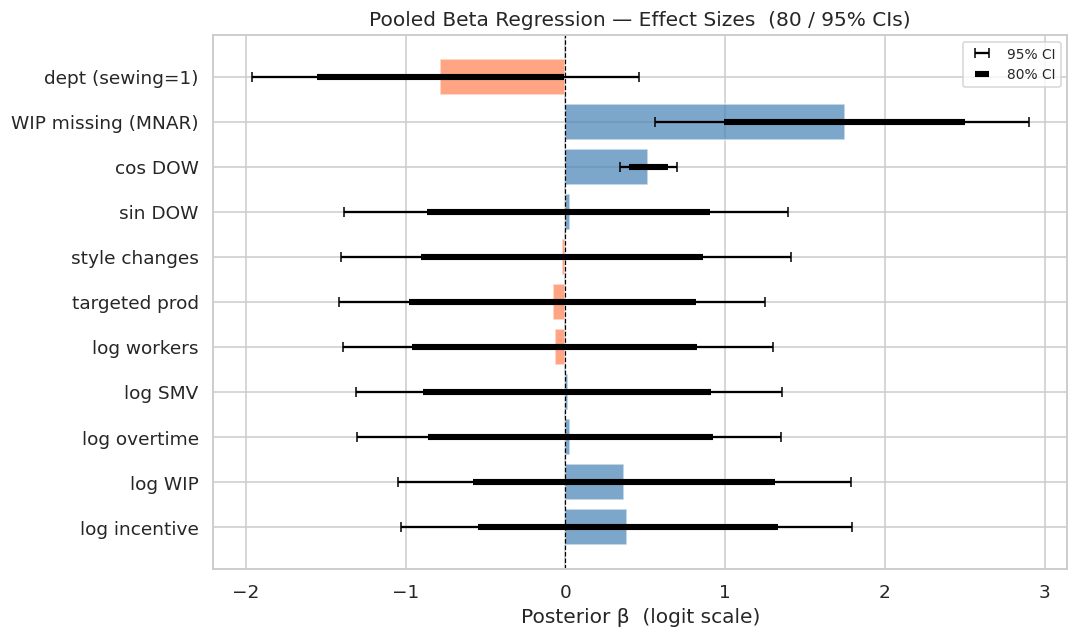

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha     0.922  0.585  -0.264    1.936      0.016    0.015    1418.0    1076.0    1.0
beta[0]   0.383  0.728  -0.885    1.807      0.019    0.019    1432.0     932.0    1.0
beta[1]   0.369  0.728  -0.983    1.701      0.019    0.019    1421.0     874.0    1.0
beta[2]   0.030  0.693  -1.181    1.364      0.015    0.016    2015.0    1566.0    1.0
beta[3]   0.015  0.694  -1.289    1.256      0.016    0.015    2007.0    1568.0    1.0
beta[4]  -0.068  0.690  -1.375    1.185      0.017    0.017    1554.0    1203.0    1.0
beta[5]  -0.076  0.690  -1.257    1.316      0.017    0.017    1558.0    1234.0    1.0
beta[6]  -0.022  0.702  -1.360    1.319      0.017    0.016    1638.0    1440.0    1.0
beta[7]   0.029  0.701  -1.265    1.393      0.017    0.016    1645.0    1449.0    1.0
beta[8]   0.518  0.094   0.351    0.694      0.002    0.002    2925.0    1364.0    1.0
beta[9]   1.748  0.594   0.666    2.893    

In [10]:
# ── Forest plot of pooled coefficients ────────────────────────────────────────
b_samp = trace_pooled.posterior['beta'].values.reshape(-1, N_CORE)
bm = b_samp.mean(0)
bl95 = np.percentile(b_samp, 2.5, axis=0);  bh95 = np.percentile(b_samp, 97.5, axis=0)
bl80 = np.percentile(b_samp, 10,  axis=0);  bh80 = np.percentile(b_samp, 90,  axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
yp = np.arange(N_CORE)
ax.barh(yp, bm, color=['steelblue' if m>0 else 'coral' for m in bm], alpha=0.7)
ax.errorbar(bm, yp, xerr=[bm-bl95, bh95-bm], fmt='none', color='black', lw=1.5, capsize=3, label='95% CI')
ax.errorbar(bm, yp, xerr=[bm-bl80, bh80-bm], fmt='none', color='black', lw=4,   capsize=0, label='80% CI')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(yp); ax.set_yticklabels(CORE_LABELS)
ax.set_xlabel('Posterior β  (logit scale)'); ax.legend(fontsize=9)
ax.set_title('Pooled Beta Regression — Effect Sizes  (80 / 95% CIs)')
plt.tight_layout(); plt.savefig(OUT/'03_pooled_coef.png', bbox_inches='tight'); plt.show()

print(az.summary(trace_pooled, var_names=['alpha','beta','phi']).to_string())


## §6 · Model 2 — Hierarchical Beta Regression

Adds partial-pooled intercepts for each of the 24 team×dept groups.

$$u_j\sim N(0,\sigma_u^2),\;j=1\ldots 24$$

Non-centred parameterisation: $u=u_{raw}\cdot\sigma_u$


In [ ]:
with pm.Model() as hier_model:
    X_data   = pm.Data('X',   X_train,   mutable=True)
    y_data   = pm.Data('y',   y_train,   mutable=True)
    grp_data = pm.Data('grp', grp_train, mutable=True)

    alpha   = pm.Normal('alpha', mu=0, sigma=1)
    beta    = pm.Normal('beta',  mu=0, sigma=1, shape=N_CORE)
    sigma_u = pm.HalfNormal('sigma_u', sigma=0.5)
    u_raw   = pm.Normal('u_raw', mu=0, sigma=1, shape=N_GROUPS)
    u       = pm.Deterministic('u', u_raw * sigma_u)
    phi     = pm.HalfNormal('phi', sigma=10)

    eta   = alpha + pm.math.dot(X_data, beta) + u[grp_data]
    mu    = pm.Deterministic('mu', pm.math.sigmoid(eta))
    y_obs = pm.Beta('y_obs', alpha=mu*phi, beta=(1-mu)*phi, observed=y_data)

    trace_hier = pm.sample(**SAMPLE_KW)

print('Hierarchical model ✓')


In [ ]:
# ── Random effects shrinkage plot ─────────────────────────────────────────────
u_post = trace_hier.posterior['u'].values.reshape(-1, N_GROUPS)
u_mean = u_post.mean(0)
u_lo95 = np.percentile(u_post, 2.5, axis=0)
u_hi95 = np.percentile(u_post, 97.5, axis=0)
order  = np.argsort(u_mean)

fig, ax = plt.subplots(figsize=(10, 8))
yp = np.arange(N_GROUPS)
ax.barh(yp, u_mean[order],
        color=['tomato' if v<0 else 'steelblue' for v in u_mean[order]], alpha=0.7)
ax.errorbar(u_mean[order], yp,
            xerr=[u_mean[order]-u_lo95[order], u_hi95[order]-u_mean[order]],
            fmt='none', color='black', lw=1.5, capsize=3)
ax.axvline(0, color='black', ls='--', lw=0.8)
ax.set_yticks(yp)
ax.set_yticklabels([f'Group {i}' for i in order])
ax.set_xlabel('Team×Dept random effect u_j  (logit scale, 95% CI)')
sigma_u_mean = trace_hier.posterior['sigma_u'].values.mean()
ax.set_title(f'Hierarchical Model — 24 Team×Dept Random Effects\n'
             f'σ_u = {sigma_u_mean:.3f}  (partial pooling strength)')
plt.tight_layout(); plt.savefig(OUT/'04_random_effects.png', bbox_inches='tight'); plt.show()

print(az.summary(trace_hier, var_names=['alpha','beta','sigma_u','phi']).to_string())
